# TSMixer as a Global ETF Sequence Model

This notebook fits one global TSMixer across the ETF panel. Parameters are
shared across ETF series, while each training example contains one ETF's target
history and covariates. The model's mixing layers therefore learn nonlinear
temporal and within-series feature interactions; they do not directly mix one
ETF's observations into another ETF's forecast. The 60-session lookback lets
the shared model reuse temporal patterns across the panel.

The question this notebook asks is whether that inductive bias pays off:
does shared nonlinear sequence modeling lift the cross-sectional IC above the Ridge
(Ch11) and GBM (Ch12) baselines on the same ETF cross-section? The results are
read back from the configured results registry - no GPU retraining happens on a
cached checkout.

**Learning Objectives**:
- Read TSMixer walk-forward checkpoint results from the configured registry
- Tune the checkpoint (epoch count) on validation via the shared grid, holdout sealed
- Place TSMixer against the linear and GBM baselines on the same cross-section
- Assess whether shared nonlinear sequence modeling lifts IC above those baselines

**Book Reference**: Chapter 13, Section 13.8 (Case Study Results)

**Prerequisites**: [`06_linear`](06_linear.ipynb), [`07_gbm`](07_gbm.ipynb),
[`09_dl_lstm`](09_dl_lstm.ipynb) (for baselines)

In [1]:
"""Global ETF TSMixer with registered walk-forward checkpoints."""

import sqlite3
import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import yaml
from IPython.display import Markdown, display

import utils.style  # noqa: F401 - activates the ML4T Plotly template
from case_studies.utils.analytics import load_best_ic_per_family
from case_studies.utils.darts_forecasting import (
    darts_training_identity,
    select_full_coverage_checkpoint,
)
from case_studies.utils.deep_learning import run_dl_cv
from case_studies.utils.latent_factors.case_study import _training_input_identity
from case_studies.utils.registry import (
    build_training_spec,
    load_prediction_metrics,
    load_prediction_sets,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
MODEL = "tsmixer"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
LOOKBACK = 60
BATCH_SIZE = 2048
MAX_FOLDS = 0

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]
    print(f"Label from setup.yaml: {PRIMARY_LABEL}")
else:
    print(f"Label override: {PRIMARY_LABEL}")

dl_config = setup.get("modeling", {}).get("dl", {}) or {}
DEVICE = dl_config.get("device", "gpu")

device_str = "cuda" if DEVICE == "gpu" and torch.cuda.is_available() else "cpu"
print(f"Case study: {CASE_STUDY_ID} | Model: {MODEL}")
print(f"Device: {device_str} | Epochs: {N_EPOCHS} | Lookback: {LOOKBACK}")

Label from setup.yaml: fwd_ret_21d
Case study: etfs | Model: tsmixer
Device: cuda | Epochs: 100 | Lookback: 60


## 1. Load Data

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
input_data_spec = _training_input_identity(CASE_STUDY_ID, PRIMARY_LABEL)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits
if MAX_FOLDS:
    splits = splits[:MAX_FOLDS]
n_features = len(feature_names)

print(f"Dataset: {len(dataset):,} rows x {n_features} features")
print(f"Label: {label_col} | Entity: {entity_col} | Folds: {len(splits)}")
print(f"Input digest: {input_data_spec['input_digest']}")

dataset_pd = dataset.to_pandas()
n_entities = dataset_pd[entity_col].nunique()
print(f"Entities: {n_entities}")

Dataset: 394,233 rows x 71 features
Label: fwd_ret_21d | Entity: symbol | Folds: 8
Input digest: sha256:8384ded464c95f36b9baff06cd6a7861db75650ff9244ac623c3c7bf662281a8
Entities: 99


## 2. Prior Baselines

The linear (Ch11) and GBM (Ch12) leaders are read from the configured registry for
the same label and validation split, rather than re-run here. They are the
reference the TSMixer result has to clear.

In [5]:
ridge_ic = float("nan")
gbm_ic = float("nan")
_baselines = load_best_ic_per_family(["linear", "gbm"], case_studies=[CASE_STUDY_ID])
for row in _baselines.iter_rows(named=True):
    if row["family"] == "linear" and row["ic_mean"] is not None:
        ridge_ic = float(row["ic_mean"])
    elif row["family"] == "gbm" and row["ic_mean"] is not None:
        gbm_ic = float(row["ic_mean"])

prior_baselines = {"Ridge (Ch11)": ridge_ic, "GBM (Ch12)": gbm_ic}
for name, ic in prior_baselines.items():
    print(f"  {name}: IC={ic:+.4f}" if np.isfinite(ic) else f"  {name}: IC=N/A")

  Ridge (Ch11): IC=+0.0421
  GBM (Ch12): IC=+0.0513


## 3. TSMixer Checkpoints

The configured results registry (`run_log/registry.db`) is the source of truth for
this case study. The TSMixer config was trained walk-forward with
cross-sectional IC evaluated at checkpoints, and each checkpoint is stored as a
prediction set with its validation IC. Here we read those checkpoints back from
the registry rather than retraining: on a cached checkout no GPU work happens
and the registry is not rewritten. Only a config with no registered
validation predictions (a fresh reader who deleted the registry) triggers a
`run_dl_cv` train.

In [6]:
dl_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "deep_learning")
dl_configs = [c for c in dl_configs if c["params"].get("architecture") == MODEL]

# Apply Papermill overrides. N_EPOCHS is part of the training spec hash, so it
# selects which registered run to read: the current registry contains the run at
# N_EPOCHS=100, and changing it here would miss the cache and trigger a fresh GPU
# train that rewrites the registry. The defaults below match the registered run, so
# these are no-ops on a cached checkout.
for cfg in dl_configs:
    if cfg.get("n_epochs", 100) != N_EPOCHS:
        cfg["n_epochs"] = N_EPOCHS
    if cfg.get("batch_size", 2048) != BATCH_SIZE:
        cfg["batch_size"] = BATCH_SIZE
    if cfg["params"].get("lookback", 60) != LOOKBACK:
        cfg["params"]["lookback"] = LOOKBACK

print(f"Grid: {len(dl_configs)} config x {len(splits)} folds (checkpoints read from registry)")
for cfg in dl_configs:
    print(f"  {cfg['config_name']}: {cfg['params'].get('architecture', '?')}")

expected_fold_ids = sorted(int(split["fold"]) for split in splits)
expected_validation_days = sum(
    dataset_pd.loc[
        (dataset_pd[date_col] >= split["val_start"]) & (dataset_pd[date_col] <= split["val_end"]),
        date_col,
    ].nunique()
    for split in splits
)

Grid: 1 config x 8 folds (checkpoints read from registry)
  tsmixer: tsmixer


In [7]:
def _rebuild_from_registry(cfg: dict) -> dict | None:
    """Rebuild one config's checkpoint curve and peak IC from the configured registry.

    Returns None if the config has no complete registered validation set (a fresh
    reader who deleted the registry), in which case it is queued for training.
    """
    identity_params = darts_training_identity(
        cfg,
        label_col,
        case_study=CASE_STUDY_ID,
        input_data_spec=input_data_spec,
        max_train_sequences=0,
    )
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(splits),
        n_epochs=cfg.get("n_epochs"),
        extra_params=identity_params,
    )
    status = training_run_status(CASE_STUDY_ID, spec)
    t_hash = training_hash_from_spec(spec)
    psets = load_prediction_sets(CASE_STUDY_ID, training_hash=t_hash, split=PREDICTION_SPLIT)
    if not status.complete or psets.is_empty():
        return None

    interval = int(cfg.get("checkpoint_interval", cfg.get("n_epochs", N_EPOCHS)))
    total_epochs = int(cfg.get("n_epochs", N_EPOCHS))
    expected_epochs = list(range(interval, total_epochs + 1, interval))
    if not expected_epochs or expected_epochs[-1] != total_epochs:
        expected_epochs.append(total_epochs)
    actual_epochs = sorted(int(value) for value in psets["checkpoint_value"].to_list())
    if actual_epochs != expected_epochs:
        return None

    curve = []
    with sqlite3.connect(CASE_DIR / "run_log" / "registry.db") as connection:
        for row in psets.iter_rows(named=True):
            prediction_hash = row["prediction_hash"]
            prediction_path = (
                CASE_DIR / "run_log" / "predictions" / prediction_hash / "predictions.parquet"
            )
            fold_ids = [
                int(item[0])
                for item in connection.execute(
                    "SELECT fold_id FROM fold_metrics WHERE prediction_hash = ? ORDER BY fold_id",
                    (prediction_hash,),
                ).fetchall()
            ]
            m = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=prediction_hash)
            if m.is_empty() or not prediction_path.exists() or fold_ids != expected_fold_ids:
                return None
            nd = m["ic_n_days"][0]
            daily_ic = m["ic_mean_daily"][0]
            if nd is None or daily_ic is None:
                return None
            curve.append(
                {
                    "config": cfg["config_name"],
                    "epoch": int(row["checkpoint_value"]),
                    "ic_mean": float(daily_ic),
                    "ic_n_days": float(nd),
                    "prediction_hash": prediction_hash,
                }
            )
    curve.sort(key=lambda c: c["epoch"])
    peak, full_days, partial_epochs = select_full_coverage_checkpoint(curve)
    if full_days != expected_validation_days:
        return None
    return {
        "config_name": cfg["config_name"],
        "best_epoch": peak["epoch"],
        "best_ic": peak["ic_mean"],
        "ic_n_days": peak["ic_n_days"],
        "best_prediction_hash": peak["prediction_hash"],
        "curve": curve,
        "full_days": full_days,
        "partial_epochs": partial_epochs,
        "cached": True,
    }


grid_results = []
to_train = []
for cfg in dl_configs:
    rebuilt = _rebuild_from_registry(cfg)
    if rebuilt is not None:
        grid_results.append(rebuilt)
        print(
            f"  {rebuilt['config_name']:10s}  epoch={rebuilt['best_epoch']:4d}  "
            f"IC={rebuilt['best_ic']:+.4f}  (cached)"
        )
    else:
        to_train.append(cfg)

# Uncached configs (none in the configured registry) train via run_dl_cv, which
# writes the registry. On a cached checkout `to_train` is empty, so no GPU work
# runs and the registry stays byte-identical.
if to_train:
    print(f"\nTraining {len(to_train)} uncached config(s)...")
    run_dl_cv(
        dataset_pd,
        splits,
        feature_names=feature_names,
        label_col=label_col,
        date_col=date_col,
        entity_col=entity_col,
        configs=to_train,
        n_features=n_features,
        device=device_str,
        save_dir=CASE_DIR / "run_log" / "training" / "deep_learning",
        register=True,
        force_retrain=FORCE_RETRAIN,
        prediction_split=PREDICTION_SPLIT,
        case_study=CASE_STUDY_ID,
        notebook=f"dl_{MODEL}",
        temporal_by_fold=mds.temporal_by_fold,
        temporal_keys=mds.temporal_keys,
        temporal_feature_names=mds.temporal_feature_names,
        input_data_spec=input_data_spec,
    )
    for cfg in to_train:
        rebuilt = _rebuild_from_registry(cfg)
        if rebuilt is None:
            raise RuntimeError(
                f"Training completed but registered checkpoints are incomplete for "
                f"{cfg['config_name']}"
            )
        rebuilt["cached"] = False
        grid_results.append(rebuilt)

  tsmixer     epoch=  10  IC=+0.0197  (cached)


## 4. Winner and Baselines

The reported IC is the config's **peak-checkpoint** validation value: the epoch
count is tuned on the validation folds by scanning the checkpoint grid and
keeping the checkpoint with the highest daily cross-sectional IC averaged over
the pooled validation dates (the epoch-count analogue of early stopping). The
holdout is never touched here.

A full-coverage guard mirrors `06_linear`, `07_gbm`, and `13_model_analysis`: a
checkpoint that collapses to near-constant predictions on some folds produces no
cross-sectional IC on those validation dates, so its IC is measured on fewer
days (`ic_n_days` below the maximum) and is not comparable. Such checkpoints are
excluded from the winner. Every checkpoint on the current registered surface
has the same 2,016-date coverage, so the guard is inert here.

In [8]:
grid_results.sort(
    key=lambda r: r["best_ic"] if np.isfinite(r["best_ic"]) else -np.inf, reverse=True
)

_finite_days = [r["ic_n_days"] for r in grid_results if np.isfinite(r.get("ic_n_days", np.nan))]
if _finite_days:
    _full_days = max(_finite_days)
    full_cov = [
        r
        for r in grid_results
        if np.isfinite(r.get("ic_n_days", np.nan)) and r["ic_n_days"] == _full_days
    ]
    partial_cov = [r for r in grid_results if r not in full_cov]
else:
    _full_days = None
    full_cov = grid_results
    partial_cov = []

best = full_cov[0] if full_cov else None
best_name = best["config_name"] if best else None
best_epoch = best["best_epoch"] if best else 0
best_ic = best["best_ic"] if best else float("nan")

print(f"{'Config':10s} {'Best Epoch':>10s} {'Peak IC':>10s} {'N Days':>8s}")
print("-" * 42)
for r in full_cov:
    marker = " *" if r is best else ""
    _nd = r.get("ic_n_days", np.nan)
    _nd_str = f"{int(_nd):>8d}" if np.isfinite(_nd) else f"{'n/a':>8s}"
    print(f"{r['config_name']:10s} {r['best_epoch']:10d} {r['best_ic']:+10.4f} {_nd_str}{marker}")

if partial_cov:
    print("\nPartial coverage (degenerate on some folds - excluded from ranking):")
    for r in partial_cov:
        _nd = r.get("ic_n_days", np.nan)
        _nd_str = f"{int(_nd)}" if np.isfinite(_nd) else "n/a"
        print(f"  {r['config_name']:10s}  IC={r['best_ic']:+.4f}  n_days={_nd_str}")

if best:
    print(f"\nBest (full coverage): {best_name} @ epoch {best_epoch} (IC={best_ic:+.4f})")
print(f"Baselines - Ridge (Ch11): {ridge_ic:+.4f} | GBM (Ch12): {gbm_ic:+.4f}")

Config     Best Epoch    Peak IC   N Days
------------------------------------------
tsmixer            10    +0.0197     2016 *

Best (full coverage): tsmixer @ epoch 10 (IC=+0.0197)
Baselines - Ridge (Ch11): +0.0421 | GBM (Ch12): +0.0513


### TSMixer against the baselines

The bar chart places the peak TSMixer IC next to the Ridge (Ch11) and GBM
(Ch12) leaders on the same label and validation split. The title is computed
from the registered values so it remains aligned with a new data vintage.

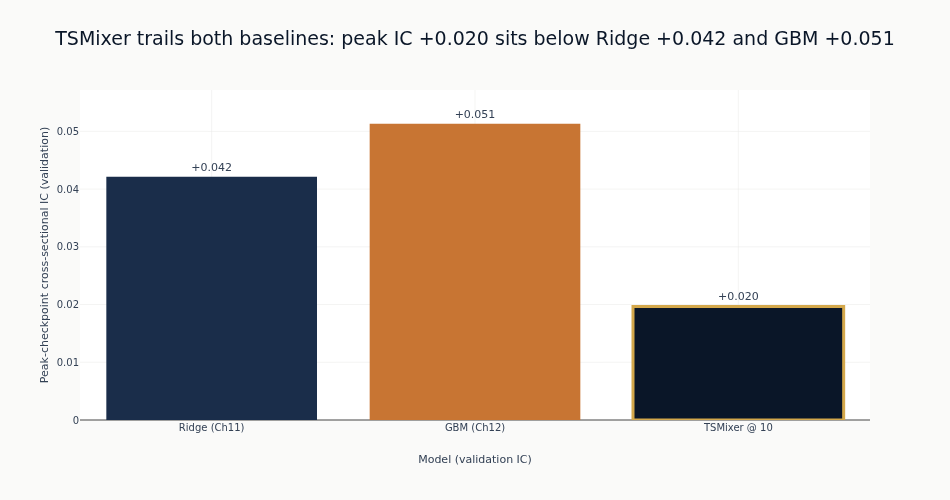

In [9]:
# IC comparison - TSMixer vs the flat-feature baselines, TSMixer outlined.
_cmp_names = ["Ridge (Ch11)", "GBM (Ch12)", f"TSMixer @ {best_epoch}"]
_cmp_ics = [ridge_ic, gbm_ic, best_ic]
_colors = [COLORS["slate"], COLORS["copper"], COLORS["blue"]]
_line_w = [0, 0, 3]
fig_cmp = go.Figure(
    go.Bar(
        x=_cmp_names,
        y=_cmp_ics,
        marker=dict(color=_colors, line=dict(color=COLORS["amber"], width=_line_w)),
        text=[f"{v:+.3f}" for v in _cmp_ics],
        textposition="outside",
        cliponaxis=False,
        showlegend=False,
    )
)
if best_ic < min(ridge_ic, gbm_ic):
    _cmp_title = (
        f"TSMixer trails both baselines: peak IC {best_ic:+.3f} sits below "
        f"Ridge {ridge_ic:+.3f} and GBM {gbm_ic:+.3f}"
    )
elif best_ic > max(ridge_ic, gbm_ic):
    _cmp_title = (
        f"TSMixer leads both baselines: peak IC {best_ic:+.3f} exceeds "
        f"Ridge {ridge_ic:+.3f} and GBM {gbm_ic:+.3f}"
    )
else:
    _cmp_title = (
        f"TSMixer sits between the baselines: peak IC {best_ic:+.3f}, "
        f"Ridge {ridge_ic:+.3f}, GBM {gbm_ic:+.3f}"
    )
fig_cmp.update_layout(
    title=_cmp_title,
    height=500,
    width=950,
    margin=dict(t=90),
)
fig_cmp.update_xaxes(title_text="Model (validation IC)")
fig_cmp.update_yaxes(title_text="Peak-checkpoint cross-sectional IC (validation)")
fig_cmp.show()

## 5. Learning Curve

Validation IC at each registered checkpoint traces how TSMixer trains. The
selected point and both baselines are computed from the registry. A
non-monotonic curve makes the checkpoint choice part of validation rather than
an assumption that the final epoch is best.

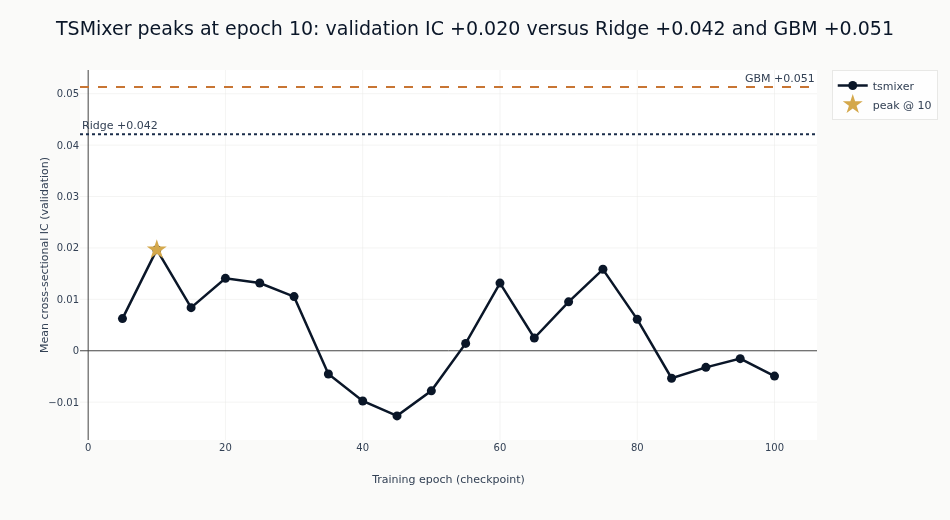

Config       epoch        IC   N days
tsmixer          5   +0.0063     2016
tsmixer         10   +0.0197     2016
tsmixer         15   +0.0084     2016
tsmixer         20   +0.0141     2016
tsmixer         25   +0.0132     2016
tsmixer         30   +0.0105     2016
tsmixer         35   -0.0045     2016
tsmixer         40   -0.0098     2016
tsmixer         45   -0.0127     2016
tsmixer         50   -0.0078     2016
tsmixer         55   +0.0014     2016
tsmixer         60   +0.0132     2016
tsmixer         65   +0.0025     2016
tsmixer         70   +0.0095     2016
tsmixer         75   +0.0158     2016
tsmixer         80   +0.0061     2016
tsmixer         85   -0.0053     2016
tsmixer         90   -0.0032     2016
tsmixer         95   -0.0015     2016
tsmixer        100   -0.0049     2016


In [10]:
all_curves = pl.DataFrame([c for r in grid_results for c in r["curve"]])
if all_curves.height > 0:
    cfg_data = all_curves.filter(pl.col("config") == best_name).sort("epoch")
    fig_lc = go.Figure(
        go.Scatter(
            x=cfg_data["epoch"].to_list(),
            y=cfg_data["ic_mean"].to_list(),
            mode="lines+markers",
            name=best_name,
            line=dict(color=COLORS["blue"], width=2.5),
            marker=dict(size=9, color=COLORS["blue"]),
        )
    )
    # Highlight the selected peak checkpoint.
    fig_lc.add_trace(
        go.Scatter(
            x=[best_epoch],
            y=[best_ic],
            mode="markers",
            name=f"peak @ {best_epoch}",
            marker=dict(size=15, color=COLORS["amber"], symbol="star"),
        )
    )
    fig_lc.add_hline(
        y=ridge_ic,
        line=dict(color=COLORS["slate"], width=2, dash="dot"),
        annotation_text=f"Ridge {ridge_ic:+.3f}",
        annotation_position="top left",
    )
    fig_lc.add_hline(
        y=gbm_ic,
        line=dict(color=COLORS["copper"], width=2, dash="dash"),
        annotation_text=f"GBM {gbm_ic:+.3f}",
        annotation_position="top right",
    )
    fig_lc.update_layout(
        title=(
            f"TSMixer peaks at epoch {best_epoch}: validation IC {best_ic:+.3f} "
            f"versus Ridge {ridge_ic:+.3f} and GBM {gbm_ic:+.3f}"
        ),
        height=520,
        width=950,
        legend=dict(title="", font=dict(size=11)),
        margin=dict(t=70),
    )
    fig_lc.update_xaxes(title_text="Training epoch (checkpoint)")
    fig_lc.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    fig_lc.show()

    print(f"{'Config':10s}{'epoch':>8s}{'IC':>10s}{'N days':>9s}")
    for c in cfg_data.iter_rows(named=True):
        print(f"{c['config']:10s}{c['epoch']:8d}{c['ic_mean']:+10.4f}{int(c['ic_n_days']):9d}")

## 6. Winner Fold Metrics

The headline validation IC is computed per date across ETFs and then averaged
over all validation dates. The per-fold values below are diagnostics for
stability, not the definition of the headline metric.

In [11]:
fold_rows = []
if best and best.get("best_prediction_hash"):
    import sqlite3

    con = sqlite3.connect(CASE_DIR / "run_log" / "registry.db")
    try:
        fold_rows = con.execute(
            "SELECT fold_id, ic, n_entities FROM fold_metrics "
            "WHERE prediction_hash = ? ORDER BY fold_id",
            (best["best_prediction_hash"],),
        ).fetchall()
    finally:
        con.close()
    print(f"Per-fold validation IC ({best_name} @ epoch {best_epoch}):")
    for fold_id, ic, n_ent in fold_rows:
        print(f"  Fold {fold_id}: IC={ic:+.4f}  n_entities={int(n_ent)}")
    _fold_mean = float(np.mean([r[1] for r in fold_rows])) if fold_rows else float("nan")
    print(f"\n  Diagnostic mean fold IC: {_fold_mean:+.4f}")
    print(f"  Registered daily-pooled IC: {best_ic:+.4f}")

Per-fold validation IC (tsmixer @ epoch 10):
  Fold 0: IC=+0.0824  n_entities=96
  Fold 1: IC=+0.0313  n_entities=97
  Fold 2: IC=-0.0092  n_entities=96
  Fold 3: IC=+0.0087  n_entities=96
  Fold 4: IC=+0.0450  n_entities=97
  Fold 5: IC=+0.0193  n_entities=95
  Fold 6: IC=-0.0065  n_entities=89
  Fold 7: IC=-0.0136  n_entities=89

  Diagnostic mean fold IC: +0.0197
  Registered daily-pooled IC: +0.0197


## 7. Registered Predictions

Every checkpoint's validation predictions are already persisted in
`run_log/registry.db`, and the backtest reads the winner's prediction set
directly. No retraining or re-saving happens on a cached checkout.

In [12]:
if best and best.get("best_prediction_hash"):
    _winner_set = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=None,
        split=PREDICTION_SPLIT,
    ).filter(pl.col("prediction_hash") == best["best_prediction_hash"])
    print(f"Winner prediction_hash: {best['best_prediction_hash']}")
    print(f"Registered checkpoints for {best_name}: {all_curves.height}")
    print(f"Winner set rows in registry: {_winner_set.height}")

Winner prediction_hash: 14a299d42118
Registered checkpoints for tsmixer: 20
Winner set rows in registry: 1


## 8. Key Takeaways

The summary below is generated from the selected registered checkpoint so its
epoch, IC, comparison, and fold-stability statements remain synchronized.

In [13]:
_negative_folds = [int(fold_id) for fold_id, ic, _ in fold_rows if ic < 0] if fold_rows else []
_negative_text = ", ".join(map(str, _negative_folds)) if _negative_folds else "none"
_baseline_reading = (
    "trails both Ridge and GBM"
    if best_ic < min(ridge_ic, gbm_ic)
    else "leads both Ridge and GBM"
    if best_ic > max(ridge_ic, gbm_ic)
    else "sits between Ridge and GBM"
)
display(
    Markdown(
        f"""
- **TSMixer {_baseline_reading}.** The full-coverage checkpoint selected at epoch
  {best_epoch} has daily-pooled validation IC {best_ic:+.4f}, versus Ridge
  {ridge_ic:+.4f} and GBM {gbm_ic:+.4f}.
- **Checkpoint selection matters.** The registered curve is non-monotonic and the
  final epoch is not assumed to be best. The epoch count is selected only on the
  validation folds; the holdout remains sealed.
- **The result is fold-fragile.** Negative fold diagnostics occur in folds
  {_negative_text}. The HAC interval should therefore carry more weight than an
  isolated strong fold.

The global model shares parameters across ETF series but does not directly mix
one ETF's observations into another ETF's forecast. Here, shared nonlinear
sequence modeling does not improve on the flat-feature baselines.

**Next**: [`11_latent_factors`](11_latent_factors.ipynb) tests whether explicit
factor structure organizes the ETF cross-section more effectively.
"""
    )
)


- **TSMixer trails both Ridge and GBM.** The full-coverage checkpoint selected at epoch
  10 has daily-pooled validation IC +0.0197, versus Ridge
  +0.0421 and GBM +0.0513.
- **Checkpoint selection matters.** The registered curve is non-monotonic and the
  final epoch is not assumed to be best. The epoch count is selected only on the
  validation folds; the holdout remains sealed.
- **The result is fold-fragile.** Negative fold diagnostics occur in folds
  2, 6, 7. The HAC interval should therefore carry more weight than an
  isolated strong fold.

The global model shares parameters across ETF series but does not directly mix
one ETF's observations into another ETF's forecast. Here, shared nonlinear
sequence modeling does not improve on the flat-feature baselines.

**Next**: [`11_latent_factors`](11_latent_factors.ipynb) tests whether explicit
factor structure organizes the ETF cross-section more effectively.


**Book**: Chapter 13.8 reports the case-study results across architectures.